In [2]:
# installing duckdb for using sql
!pip install duckdb

In [3]:
# importing libraries
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# loading datasets
!gdown 10V16cSubPZ3-OT0U6cVmcSgCoaekicrB
!gdown 1ppxDfOZtYdudtjzD-DrRjt8VkniqoytI

Downloading...
From: https://drive.google.com/uc?id=10V16cSubPZ3-OT0U6cVmcSgCoaekicrB
To: /content/Dataset 1 Awardees AFWH.csv
100% 5.12k/5.12k [00:00<00:00, 11.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ppxDfOZtYdudtjzD-DrRjt8VkniqoytI
To: /content/Dataset 2 UN Countries.csv
100% 14.8k/14.8k [00:00<00:00, 34.5MB/s]


In [5]:
# reading datasets
df1 = pd.read_csv("/content/Dataset 1 Awardees AFWH.csv")
df2 = pd.read_csv("/content/Dataset 2 UN Countries.csv")

In [6]:
# replacing - and ' '(space) with _ (underscores) in field names
df1.columns = df1.columns.str.replace(' ', '_').str.lower()
df2.columns = df2.columns.str.replace(' ', '_').str.lower()

df1.columns = df1.columns.str.replace('-', '_').str.lower()
df2.columns = df2.columns.str.replace('-', '_').str.lower()

In [7]:
# aligning the country names
newdf1 = duckdb.query("""
    SELECT
        *,
        CASE
            WHEN hq_country = 'US' THEN 'United States of America'
            WHEN hq_country = 'The Netherlands' THEN 'Netherlands'
            WHEN hq_country = 'United Kingdom' THEN 'United Kingdom of Great Britain and Northern Ireland'
            ELSE hq_country
        END AS country
    FROM df1
""").df()

In [8]:
# question 1 part 1 - joining both dataframes and getting one main dataframe
ques1pt1 = '''
select newdf1.*, df2.*
from newdf1
left join df2
on newdf1.country = df2.location
'''

ques1pt1 = duckdb.query(ques1pt1).df()  # returns a pandas DataFrame
ques1pt1.tail(50)

,lead_organization,open_call,hq_country,country,location,sub_region,alpha3_/_m49,sub_region_m49_code,2022_population,world_bank_lending_group_2026
33,Doris Mollel Foundation,Action for Women's Health,Tanzania,Tanzania,Tanzania,Eastern Africa,tza,14,"65,497,748",Lower middle income
34,Women's Cancer Resource Center,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
35,Women In Transition,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
36,West Alabama Women's Center Inc. (DBA WAWC Hea...,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
37,"We Care Solar, Inc.",Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
38,Tigerlily Foundation,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
39,The Nia Project,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
40,The Floating Hospital,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
41,"Sundari Foundation, Inc.",Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income
42,StrongMinds,Action for Women's Health,US,United States of America,United States of America,Northern America,usa,21,"333,287,557",High income


In [9]:
# question 1 part 2 - counting the total number of organizations and their percntages by sug-region
ques1pt2 = '''
    SELECT
    sub_region,
    COUNT(lead_organization) AS count_of_orgs,
    ROUND(COUNT(lead_organization) * 100.0 / SUM(COUNT(lead_organization)) OVER (), 2) AS percentage
FROM ques1pt1
GROUP BY sub_region
ORDER BY count_of_orgs DESC;'''

ques1pt2 = duckdb.query(ques1pt2).df()  # returns a pandas DataFrame
ques1pt2

,sub_region,count_of_orgs,percentage
0,Northern America,51,61.45
1,Eastern Africa,6,7.23
2,South America,4,4.82
3,Southern Asia,4,4.82
4,Central America,3,3.61
5,Southern Africa,3,3.61
6,Australasia,2,2.41
7,Western Europe,2,2.41
8,Northern Europe,2,2.41
9,Southeastern Asia,2,2.41


In [10]:
# question 1 part 3 - counting the total number of organizations and their percntages by income level
ques1pt3 = '''
    SELECT
    world_bank_lending_group_2026,
    COUNT(lead_organization) AS count_of_orgs,
    ROUND(COUNT(lead_organization) * 100.0 / SUM(COUNT(lead_organization)) OVER (), 2) AS percentage
FROM ques1pt1
GROUP BY world_bank_lending_group_2026
ORDER BY count_of_orgs DESC;'''

ques1pt3 = duckdb.query(ques1pt3).df()  # returns a pandas DataFrame
ques1pt3

,world_bank_lending_group_2026,count_of_orgs,percentage
0,High income,58,69.88
1,Upper middle income,11,13.25
2,Lower middle income,11,13.25
3,Low income,3,3.61


In [11]:
# question 1 part 4 - grouping countries by sub-region and calculating the count and percentage of each World Bank lending group (Low, Lower Middle, Upper Middle, High income) within each sub-region, ordered by total country count

ques1pt4 = '''
    Select
    sub_region,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'Low income' THEN 1 ELSE 0 END) AS low_income,
    ROUND(SUM(CASE WHEN world_bank_lending_group_2026 = 'Low income' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS low_income_pct,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'Lower middle income' THEN 1 ELSE 0 END) AS lower_middle_income,
    ROUND(SUM(CASE WHEN world_bank_lending_group_2026 = 'Lower middle income' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS lower_middle_pct,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'Upper middle income' THEN 1 ELSE 0 END) AS upper_middle_income,
    ROUND(SUM(CASE WHEN world_bank_lending_group_2026 = 'Upper middle income' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS upper_middle_pct,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'High income' THEN 1 ELSE 0 END) AS high_income,
    ROUND(SUM(CASE WHEN world_bank_lending_group_2026 = 'High income' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS high_income_pct,
    COUNT(lead_organization) AS total
FROM ques1pt1
GROUP BY sub_region
ORDER BY total DESC;'''

ques1pt4 = duckdb.query(ques1pt4).df()
ques1pt4

,sub_region,low_income,low_income_pct,lower_middle_income,lower_middle_pct,upper_middle_income,upper_middle_pct,high_income,high_income_pct,total
0,Northern America,0.0,0.0,0.0,0.0,0.0,0.0,51.0,100.0,51
1,Eastern Africa,3.0,50.0,3.0,50.0,0.0,0.0,0.0,0.0,6
2,South America,0.0,0.0,0.0,0.0,4.0,100.0,0.0,0.0,4
3,Southern Asia,0.0,0.0,4.0,100.0,0.0,0.0,0.0,0.0,4
4,Central America,0.0,0.0,0.0,0.0,3.0,100.0,0.0,0.0,3
5,Southern Africa,0.0,0.0,1.0,33.3,2.0,66.7,0.0,0.0,3
6,Australasia,0.0,0.0,0.0,0.0,0.0,0.0,2.0,100.0,2
7,Northern Europe,0.0,0.0,0.0,0.0,0.0,0.0,2.0,100.0,2
8,Western Europe,0.0,0.0,0.0,0.0,0.0,0.0,2.0,100.0,2
9,Southeastern Asia,0.0,0.0,1.0,50.0,1.0,50.0,0.0,0.0,2


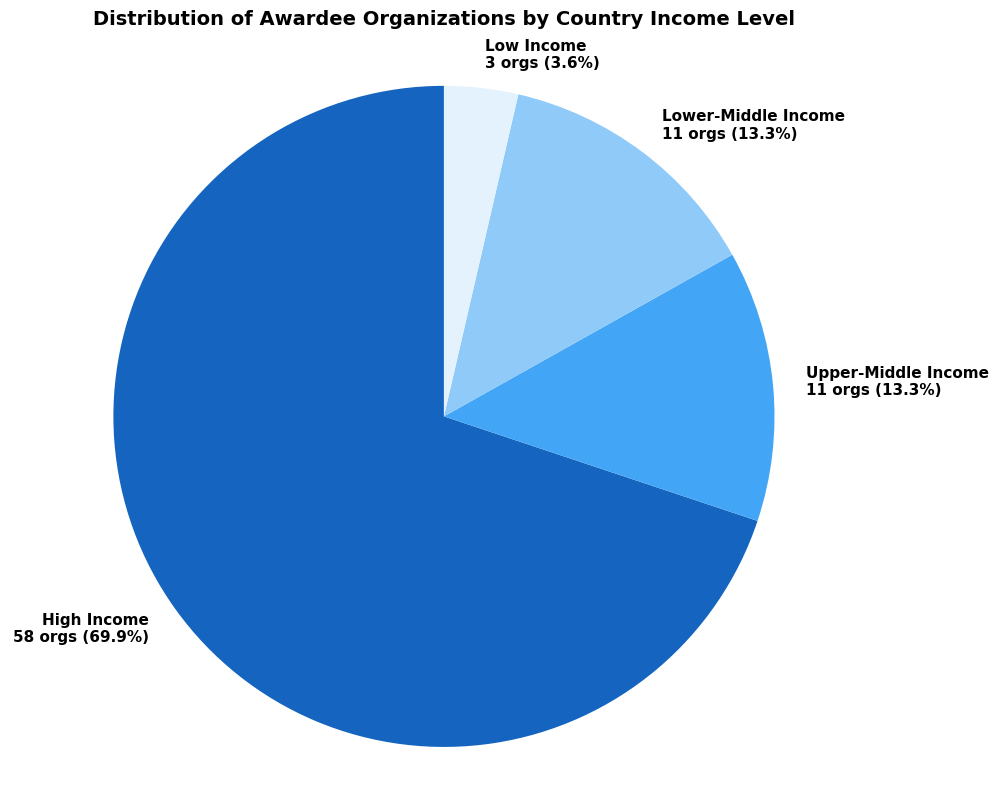

In [12]:
# pie chart showing the "Distribution of Awardee Organizations by Country Income Level"

# Your data
income_levels = ['High Income', 'Upper-Middle Income', 'Lower-Middle Income', 'Low Income']
counts = [58, 11, 11, 3]

# Create labels with both count and percentage
labels_with_counts = [f'{level}\n{count} orgs ({count/83*100:.1f}%)'
                      for level, count in zip(income_levels, counts)]

# Create pie chart
plt.figure(figsize=(10, 8))
colors = ['#1565C0', '#42A5F5', '#90CAF9', '#E3F2FD']  # Blue gradient

wedges, texts = plt.pie(
    counts,
    labels=labels_with_counts,
    colors=colors,
    startangle=90,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

# Add title
plt.title('Distribution of Awardee Organizations by Country Income Level',
          fontsize=14, fontweight='bold', pad=20)

plt.axis('equal')
plt.tight_layout()
plt.show()

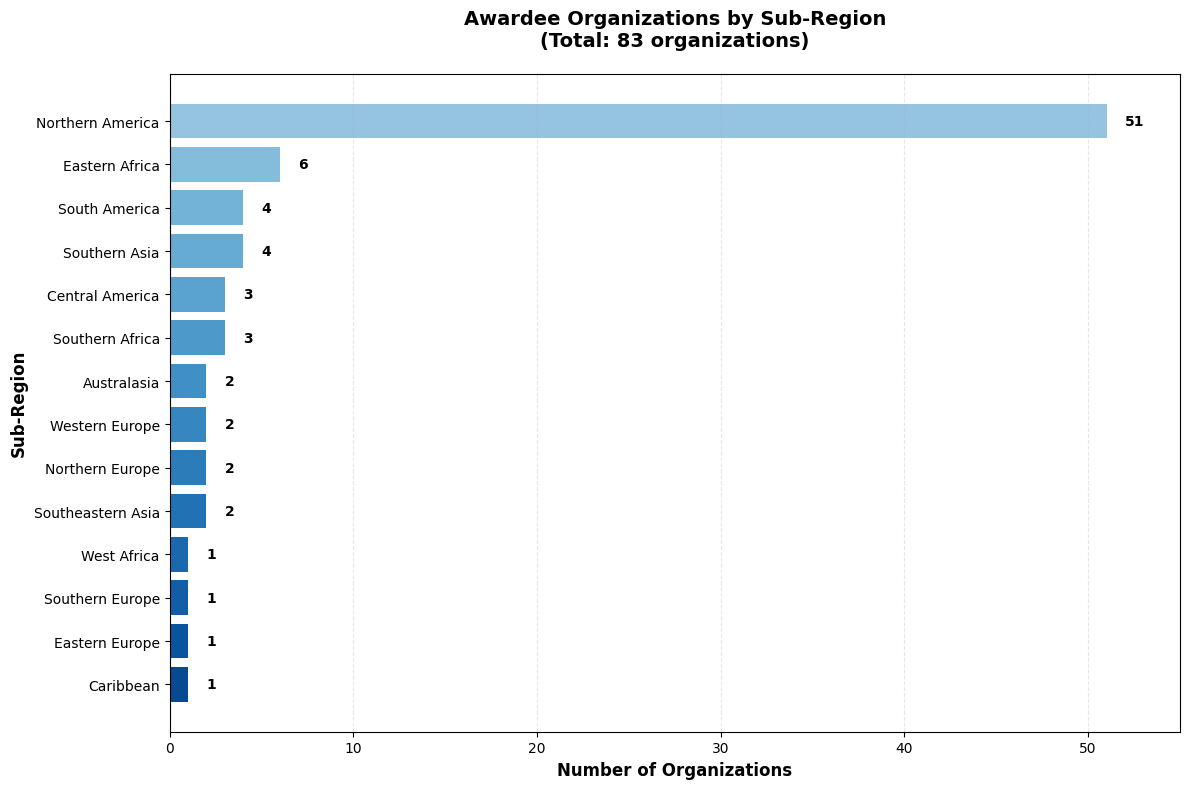

In [13]:
# bar chart showing "Awardee Organizations by Sub-Region\n(Total: 83 organizations)"

df_subregion = ques1pt2

# Create color gradient (darker for more orgs)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df_subregion)))

# Create chart
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(df_subregion['sub_region'], df_subregion['count_of_orgs'], color=colors)

# Add labels
for i, (region, count) in enumerate(zip(df_subregion['sub_region'], df_subregion['count_of_orgs'])):
    ax.text(count + 1, i, str(count), va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Organizations', fontsize=12, fontweight='bold')
ax.set_ylabel('Sub-Region', fontsize=12, fontweight='bold')
ax.set_title('Awardee Organizations by Sub-Region\n(Total: 83 organizations)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 55)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

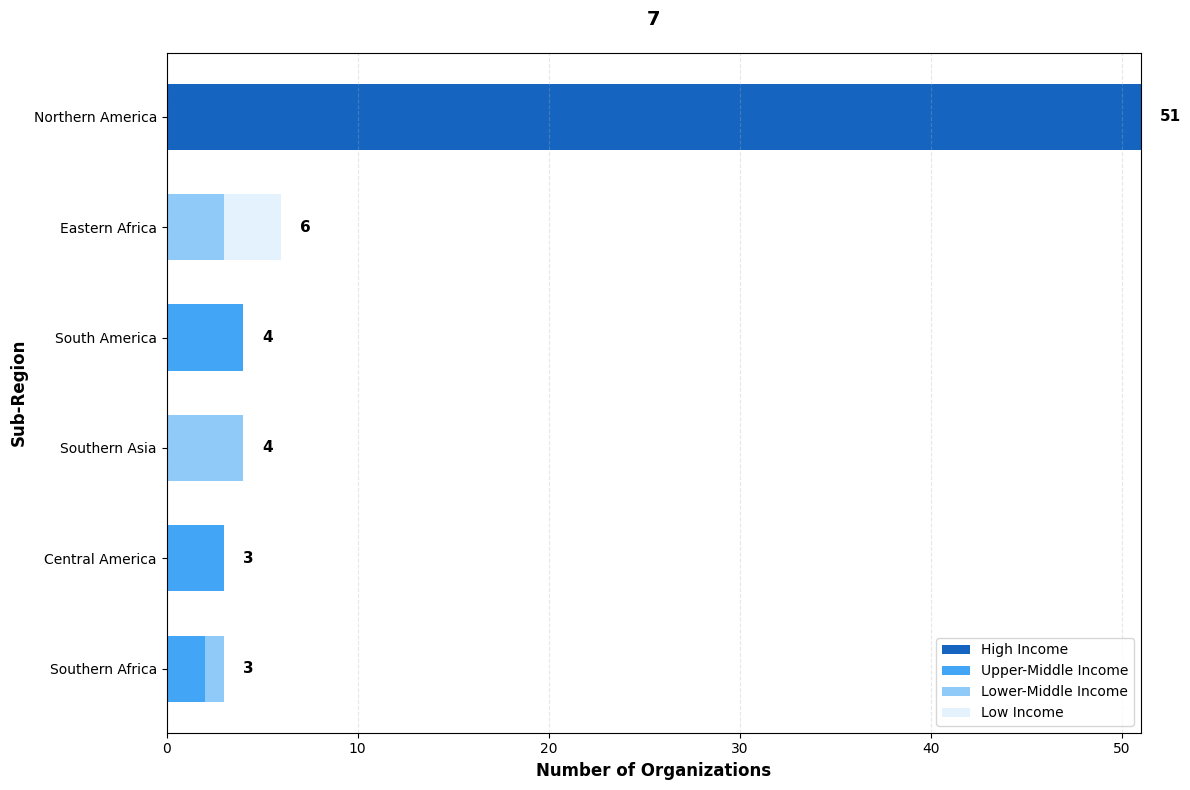

In [14]:
# showing stacked bar chart showing "Awardee Organizations by Sub-Region and Income Level"

# Get top 4 regions with income breakdown
crosstab_query = '''
SELECT
    sub_region,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'High income' THEN 1 ELSE 0 END) AS high_income,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'Upper middle income' THEN 1 ELSE 0 END) AS upper_middle_income,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'Lower middle income' THEN 1 ELSE 0 END) AS lower_middle_income,
    SUM(CASE WHEN world_bank_lending_group_2026 = 'Low income' THEN 1 ELSE 0 END) AS low_income,
    COUNT(lead_organization) AS total
FROM ques1pt1
GROUP BY sub_region
ORDER BY total DESC
LIMIT 6;
'''

df_crosstab = duckdb.query(crosstab_query).df()

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Colors matching your pie chart (same order)
colors = {
    'high_income': '#1565C0',
    'upper_middle_income': '#42A5F5',
    'lower_middle_income': '#90CAF9',
    'low_income': '#E3F2FD'
}

# Create stacked bars
x = range(len(df_crosstab))
width = 0.6

# Stack the bars
bar1 = ax.barh(x, df_crosstab['high_income'], width,
               label='High Income', color=colors['high_income'])
bar2 = ax.barh(x, df_crosstab['upper_middle_income'], width,
               left=df_crosstab['high_income'],
               label='Upper-Middle Income', color=colors['upper_middle_income'])
bar3 = ax.barh(x, df_crosstab['lower_middle_income'], width,
               left=df_crosstab['high_income'] + df_crosstab['upper_middle_income'],
               label='Lower-Middle Income', color=colors['lower_middle_income'])
bar4 = ax.barh(x, df_crosstab['low_income'], width,
               left=df_crosstab['high_income'] + df_crosstab['upper_middle_income'] + df_crosstab['lower_middle_income'],
               label='Low Income', color=colors['low_income'])

# Add total labels at end of bars
for i, total in enumerate(df_crosstab['total']):
    ax.text(total + 1, i, str(total), va='center', fontsize=11, fontweight='bold')

# Formatting
ax.set_yticks(x)
ax.set_yticklabels(df_crosstab['sub_region'])
ax.set_xlabel('Number of Organizations', fontsize=12, fontweight='bold')
ax.set_ylabel('Sub-Region', fontsize=12, fontweight='bold')
ax.set_title('7',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()  # Highest at top

plt.tight_layout()
plt.show()

In [15]:
# question 2 part 1 - changing the population from string to integer
ques2pt1 = '''
SELECT
    sub_region,
    lead_organization,
    CAST(REPLACE("2022_population", ',', '') AS BIGINT) AS population,
    location
FROM ques1pt1
ORDER BY population desc;
'''

ques2pt1 = duckdb.query(ques2pt1).df()
ques2pt1


,sub_region,lead_organization,population,location
0,Southern Asia,The Antara Foundation,1417173173,India
1,Southern Asia,Centre for Advocacy and Research,1417173173,India
2,Southern Asia,Cancer Awareness Prevention and Early Detectio...,1417173173,India
3,Northern America,Young Women's Christian Association San Antonio,333287557,United States of America
4,Northern America,"Women's Housing Coalition, Inc.",333287557,United States of America
...,...,...,...,...
78,West Africa,Educational Technology and Research Internatio...,13352864,Benin
79,Caribbean,Les Centres GHESKIO,11584996,Haiti
80,Southern Europe,Melissa Network of Migrant Women in Greece,10426919,Greece
81,Western Europe,MMV Medicines for Malaria Venture,8775760,Switzerland


In [16]:
# question 2 part 2 - getting distinct country and their population so that they are just being counted once
ques2pt2 = '''
select
distinct location,
population,
sub_region,
from ques2pt1
'''

ques2pt2 = duckdb.query(ques2pt2).df()
ques2pt2

,location,population,sub_region
0,United States of America,333287557,Northern America
1,Indonesia,275501339,Southeastern Asia
2,Brazil,215313498,South America
3,Mexico,127504125,Central America
4,Philippines,115559009,Southeastern Asia
5,South Africa,59893885,Southern Africa
6,Argentina,46234830,South America
7,Nepal,30547580,Southern Asia
8,Australia,26005540,Australasia
9,Haiti,11584996,Caribbean


In [17]:
# question 2 part 3 - getting total population in a sub-region
ques2pt3 = '''
select
sub_region,
sum(population) as total_population_in_sub_region
from ques2pt1
group by sub_region
'''

ques2pt3 = duckdb.query(ques2pt3).df()
ques2pt3

,sub_region,total_population_in_sub_region
0,Southern Asia,4.282067e+09
1,Southeastern Asia,3.910603e+08
2,South America,3.652964e+08
3,Northern Europe,7.287443e+07
4,Southern Africa,1.361083e+08
5,Caribbean,1.158500e+07
6,Northern America,1.699767e+10
7,Central America,3.825124e+08
8,Eastern Africa,3.239619e+08
9,Eastern Europe,3.800000e+07


In [18]:
# question 2 part 4 - total population and total organizations in a sub-region
ques2pt4 = '''
select ques2pt3.*, ques1pt2.count_of_orgs
from ques2pt3
left join ques1pt2
on ques2pt3.sub_region = ques1pt2.sub_region
'''

ques2pt4 = duckdb.query(ques2pt4).df()
ques2pt4

,sub_region,total_population_in_sub_region,count_of_orgs
0,Southern Asia,4.282067e+09,4
1,Southeastern Asia,3.910603e+08,2
2,South America,3.652964e+08,4
3,Northern Europe,7.287443e+07,2
4,Southern Africa,1.361083e+08,3
5,Caribbean,1.158500e+07,1
6,Northern America,1.699767e+10,51
7,Central America,3.825124e+08,3
8,Eastern Africa,3.239619e+08,6
9,Eastern Europe,3.800000e+07,1


In [19]:
# registering question 2 part 4 for further analysis
duckdb.register('ques2pt4_df', ques2pt4)

# question 2 part 5 - calculating organizations per million, perent of total organizations in a sub-region, percent of total population in a sub-region
ques2pt5 = '''
SELECT *,
    ROUND((count_of_orgs * 1000000.0) / total_population_in_sub_region, 3) AS orgs_per_million,
    ROUND((count_of_orgs * 100.0) / SUM(count_of_orgs) OVER (), 2) AS pct_of_total_orgs,
    ROUND((total_population_in_sub_region * 100.0) / SUM(total_population_in_sub_region) OVER (), 2) AS pct_of_total_population
FROM ques2pt4_df
ORDER BY total_population_in_sub_region DESC;
'''

ques2pt5 = duckdb.query(ques2pt5).df()
ques2pt5

,sub_region,total_population_in_sub_region,count_of_orgs,orgs_per_million,pct_of_total_orgs,pct_of_total_population
0,Northern America,1.699767e+10,51,0.003,61.45,73.57
1,Southern Asia,4.282067e+09,4,0.001,4.82,18.53
2,Southeastern Asia,3.910603e+08,2,0.005,2.41,1.69
3,Central America,3.825124e+08,3,0.008,3.61,1.66
4,South America,3.652964e+08,4,0.011,4.82,1.58
5,Eastern Africa,3.239619e+08,6,0.019,7.23,1.40
6,Southern Africa,1.361083e+08,3,0.022,3.61,0.59
7,Northern Europe,7.287443e+07,2,0.027,2.41,0.32
8,Australasia,5.201108e+07,2,0.038,2.41,0.23
9,Eastern Europe,3.800000e+07,1,0.026,1.20,0.16
